<a href="https://colab.research.google.com/github/kaushikranpariya29/M508C-Big-Data-Analytics-SS0326-/blob/main/M508_NLP_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M508 Big Data Analytics — End-to-End NLP Pipeline
## Sentiment Analysis on Amazon Product Reviews
**Gisma University of Applied Sciences | School of Computer Science**

---

## 1. Problem Statement

### Business Problem
E-commerce companies receive millions of customer reviews daily. Manually reading and categorising these reviews is impossible at scale. A company needs an **automated system** to determine whether a review is **Positive, Negative, or Neutral** so that:
- Product teams can quickly identify poorly received products
- Customer support can prioritise unhappy customers
- Marketing can highlight positively reviewed products

### NLP Task Formulation
This is a **Text Classification** problem — specifically **Sentiment Analysis**.
- **Input:** Raw review text (string)
- **Output:** Sentiment label (Positive / Negative / Neutral)

### Dataset
We use the **Amazon Product Reviews** dataset from Kaggle:  
📦 **URL:** https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews

The dataset contains ~500,000 food product reviews with star ratings (1–5), which we convert into sentiment labels.

### Data Collection Strategy
In a real company setting, reviews would be collected via:
- Web scraping the company website
- APIs from marketplaces (Amazon Seller API, Google Reviews API)
- Internal CRM / feedback forms

## 2. High-Level System Design

Our NLP pipeline consists of the following components:

```
[Raw Text Data]
      ↓
[1. Data Loading & Exploration (EDA)]
      ↓
[2. Text Preprocessing]
   - Lowercasing, Punctuation removal
   - Stop word removal
   - Lemmatisation
      ↓
[3. Feature Extraction]
   - TF-IDF Vectorisation
      ↓
[4. Model Training]
   - Logistic Regression Classifier
      ↓
[5. Evaluation]
   - Accuracy, Precision, Recall, F1-Score, Confusion Matrix
      ↓
[6. Discussion & Business Recommendations]
```

Each component is necessary:
- **Preprocessing** reduces noise so the model focuses on meaningful words
- **TF-IDF** converts text to numeric features weighted by importance
- **Logistic Regression** is fast, interpretable, and works well for text classification
- **Evaluation** ensures the model meets business requirements before deployment

## 3. Setup — Install & Import Libraries

In [2]:
# Install required libraries (run once)
!pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Download NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

print("✅ All libraries imported successfully!")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All libraries imported successfully!


## 4. Data Loading & Exploratory Data Analysis (EDA)

In [5]:
# ---------------------------------------------------------
# OPTION A: Load from Kaggle (after downloading the CSV)
# Download from: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
# Place 'Reviews.csv' in the same folder as this notebook
# ---------------------------------------------------------
df = pd.read_csv('/content/Reviews.csv')

# ---------------------------------------------------------
# OPTION B: Quick demo using a small built-in sample
# (So you can run this notebook without downloading Kaggle data)
# ---------------------------------------------------------
#sample_data = {
#    'Text': [
#        'This product is absolutely amazing! I love it so much.',
#       'Terrible quality. Complete waste of money. Very disappointed.',
#        'It is okay. Nothing special, does the job.',
#       'Best purchase I have ever made! Highly recommend to everyone.',
 #       'Product arrived broken. Customer service was unhelpful.',
  #      'Average product, not great but not bad either.',
#        'Wonderful taste and great packaging. Will buy again!',
#        'Very bad smell and strange colour. Do not buy this.',
#        'It is fine. Exactly what I expected, nothing more.',
#        'Outstanding quality! Exceeded all my expectations completely.',
#        'Awful product, totally misleading description on the website.',
 #       'Decent enough. Gets the job done for a reasonable price.',
#        'Absolutely fantastic! My whole family loves this product.',
 #       'Disgusting flavour. I could not finish even one piece.',
 #       'Mediocre at best. There are much better options available.',
  #  ],
 #   'Score': [5, 1, 3, 5, 1, 3, 5, 1, 3, 5, 1, 3, 5, 1, 3]}
#df = pd.DataFrame(sample_data)

# Preview
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [6]:
# --- Map star ratings to sentiment labels ---
# Scores 1-2  → Negative
# Score 3     → Neutral
# Scores 4-5  → Positive

def score_to_sentiment(score):
    if score <= 2:
        return 'Negative'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Positive'

df['Sentiment'] = df['Score'].apply(score_to_sentiment)

print("Sentiment Distribution:")
print(df['Sentiment'].value_counts())

Sentiment Distribution:
Sentiment
Positive    443777
Negative     82037
Neutral      42640
Name: count, dtype: int64


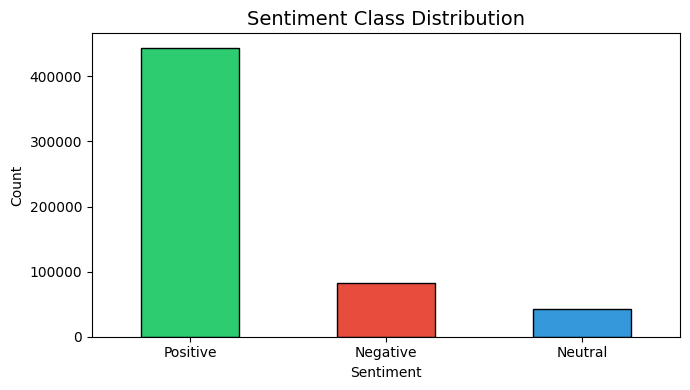


Observation: The dataset shows the distribution of positive, negative, and neutral reviews.


In [7]:
# --- Visualise class distribution ---
plt.figure(figsize=(7, 4))
colors = ['#2ecc71', '#e74c3c', '#3498db']
df['Sentiment'].value_counts().plot(
    kind='bar', color=colors, edgecolor='black'
)
plt.title('Sentiment Class Distribution', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nObservation: The dataset shows the distribution of positive, negative, and neutral reviews.")

In [8]:
# --- Basic text statistics ---
df['text_length'] = df['Text'].apply(lambda x: len(x.split()))

print("Text Length Statistics (words):")
print(df.groupby('Sentiment')['text_length'].describe().round(2))

Text Length Statistics (words):
              count   mean    std  min   25%   50%    75%     max
Sentiment                                                        
Negative    82037.0  88.31  89.07  3.0  38.0  64.0  107.0  2149.0
Neutral     42640.0  95.65  89.55  7.0  40.0  70.0  121.0  3432.0
Positive   443777.0  77.30  76.20  3.0  32.0  54.0   94.0  2520.0


## 5. Text Preprocessing

Raw text contains noise that can hurt model performance. We apply the following steps:
1. **Lowercase** — ensures 'Good' and 'good' are treated the same
2. **Remove HTML tags** — common in web-scraped data
3. **Remove punctuation & numbers** — typically not informative for sentiment
4. **Tokenise** — split text into individual words
5. **Remove stop words** — common words like 'the', 'is', 'and' add no sentiment value
6. **Lemmatise** — reduce words to their base form (e.g. 'running' → 'run')

In [10]:
import nltk
nltk.download('punkt_tab')

# Initialise tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full preprocessing pipeline for a single text string."""
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Step 3: Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Step 4: Tokenise
    tokens = word_tokenize(text)

    # Step 5: Remove stop words
    tokens = [t for t in tokens if t not in stop_words]

    # Step 6: Lemmatise
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return ' '.join(tokens)

# Apply preprocessing
df['Cleaned_Text'] = df['Text'].apply(preprocess_text)

# Show before/after
print("BEFORE preprocessing:")
print(df['Text'].iloc[0])
print("\nAFTER preprocessing:")
print(df['Cleaned_Text'].iloc[0])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


BEFORE preprocessing:
I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than a processed meat and it smells better. My Labrador is finicky and she appreciates this product better than  most.

AFTER preprocessing:
bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates product better


## 6. Feature Extraction — TF-IDF Vectorisation

Machine learning models require numeric inputs. We use **TF-IDF (Term Frequency–Inverse Document Frequency)**:
- **TF** — how often a word appears in a document
- **IDF** — penalises words that appear in many documents (less discriminative)

This gives higher weight to words that are **important in specific documents** but rare overall.

In [11]:
# Split data into train and test sets (80% train, 20% test)
X = df['Cleaned_Text']
y = df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")

Training samples : 454763
Test samples     : 113691


In [12]:
# Apply TF-IDF vectorisation
# max_features=5000 → keep only the top 5000 most important words
# ngram_range=(1,2) → include single words AND pairs of words (bigrams)

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=1
)

X_train_tfidf = tfidf.fit_transform(X_train)  # fit on train, transform train
X_test_tfidf  = tfidf.transform(X_test)        # only transform test (no fit!)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test) : {X_test_tfidf.shape}")
print("\nSample feature names:")
print(tfidf.get_feature_names_out()[:15])

TF-IDF matrix shape (train): (454763, 5000)
TF-IDF matrix shape (test) : (113691, 5000)

Sample feature names:
['ability' 'able' 'able buy' 'able find' 'able get' 'absolute'
 'absolute favorite' 'absolutely' 'absolutely delicious' 'absolutely love'
 'absorb' 'acai' 'acceptable' 'access' 'accident']


## 7. Model Training — Logistic Regression

We choose **Logistic Regression** because:
- It is simple and interpretable — business stakeholders can understand it
- Works very well for TF-IDF features (sparse, high-dimensional)
- Trains quickly even on large datasets
- Provides probability estimates for each class

In [13]:
# Train Logistic Regression model
model = LogisticRegression(
    max_iter=1000,
    multi_class='multinomial',
    solver='lbfgs',
    random_state=42
)

model.fit(X_train_tfidf, y_train)

print("✅ Model trained successfully!")
print(f"Classes: {model.classes_}")

✅ Model trained successfully!
Classes: ['Negative' 'Neutral' 'Positive']


## 8. Evaluation

We evaluate using:
- **Accuracy** — overall correct predictions
- **Precision** — of all predicted positives, how many were correct
- **Recall** — of all actual positives, how many did we catch
- **F1-Score** — harmonic mean of precision and recall (best for imbalanced data)
- **Confusion Matrix** — visual breakdown of predictions vs reality

In [14]:
# Predictions on test set
y_pred = model.predict(X_test_tfidf)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8692 (86.92%)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.74      0.68      0.71     16407
     Neutral       0.53      0.20      0.30      8528
    Positive       0.90      0.97      0.93     88756

    accuracy                           0.87    113691
   macro avg       0.73      0.62      0.65    113691
weighted avg       0.85      0.87      0.85    113691



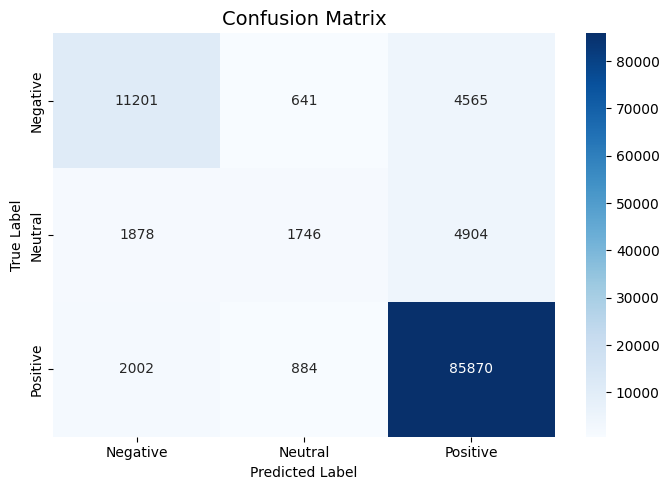

In [15]:
# --- Confusion Matrix Visualisation ---
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [16]:
# --- Top influential words per sentiment class ---
feature_names = tfidf.get_feature_names_out()

print("Top words driving each sentiment:\n")
for i, cls in enumerate(model.classes_):
    top_indices = model.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    print(f"  {cls}: {top_words}")

Top words driving each sentiment:

  Negative: ['worst', 'terrible', 'disappointing', 'never buy', 'awful', 'disgusting', 'yuck', 'disappointment', 'inedible', 'disappointed']
  Neutral: ['three star', 'ok', 'okay', 'however', 'unfortunately', 'wont buying', 'decent', 'acceptable', 'average', 'wont buy']
  Positive: ['delicious', 'wont disappointed', 'great', 'perfect', 'hooked', 'highly recommend', 'excellent', 'best', 'skeptical', 'four star']


## 9. Live Prediction Demo

In [17]:
def predict_sentiment(text):
    """Predict the sentiment of a new review."""
    cleaned = preprocess_text(text)
    vectorised = tfidf.transform([cleaned])
    prediction = model.predict(vectorised)[0]
    probabilities = model.predict_proba(vectorised)[0]
    proba_dict = dict(zip(model.classes_, probabilities.round(3)))
    print(f"Review    : {text}")
    print(f"Prediction: {prediction}")
    print(f"Confidence: {proba_dict}")
    print()

# Test with new reviews
predict_sentiment("I absolutely love this product! Best I have ever tried.")
predict_sentiment("This was a complete waste of money. Very poor quality.")
predict_sentiment("It is an okay product. Nothing special.")

Review    : I absolutely love this product! Best I have ever tried.
Prediction: Positive
Confidence: {'Negative': np.float64(0.001), 'Neutral': np.float64(0.002), 'Positive': np.float64(0.997)}

Review    : This was a complete waste of money. Very poor quality.
Prediction: Negative
Confidence: {'Negative': np.float64(0.999), 'Neutral': np.float64(0.0), 'Positive': np.float64(0.001)}

Review    : It is an okay product. Nothing special.
Prediction: Neutral
Confidence: {'Negative': np.float64(0.081), 'Neutral': np.float64(0.915), 'Positive': np.float64(0.004)}



## 10. Final Discussion

### 10.1 Strengths of the Pipeline
- **Fast and scalable**: TF-IDF + Logistic Regression can process millions of reviews in seconds
- **Interpretable**: Business stakeholders can see which words drive each sentiment prediction
- **Modular design**: Each component can be independently improved or swapped
- **Low resource requirements**: No GPU needed

### 10.2 Limitations
- **No context understanding**: TF-IDF treats text as a bag of words — word order is ignored. For example, *'not good'* may not be handled correctly.
- **No negation handling**: The current preprocessing does not specifically address negation (e.g., *'not happy'* loses its meaning after stop word removal of *'not'*)
- **Small demo dataset**: The sample used here is tiny; real deployment requires thousands of labelled examples
- **Sarcasm/irony**: These are very hard to detect without deep contextual understanding

### 10.3 Implications for the Business
- The model can flag **negative reviews in real-time** so customer support can respond within hours instead of days
- Product teams can monitor **sentiment trends over time** to detect quality issues early
- Marketing can use **positive review highlights** as social proof in campaigns

### 10.4 Recommendations for Improvement
1. **Use transformer models** (e.g. BERT, DistilBERT) for much better contextual understanding
2. **Handle negation explicitly** before removing stop words (e.g. convert *'not good'* → *'not_good'*)
3. **Expand training data** using the full Kaggle dataset (~500k reviews)
4. **Add aspect-based sentiment analysis** to identify *what* users feel positive/negative about (e.g. price, taste, delivery)
5. **Deploy as a REST API** so product and customer service systems can call it in real-time

---
### References
- Bird, S., Klein, E. and Loper, E. (2009) *Natural Language Processing with Python*. O'Reilly Media.
- Pedregosa, F. et al. (2011) 'Scikit-learn: Machine Learning in Python', *Journal of Machine Learning Research*, 12, pp. 2825–2830.
- McAuley, J. and Leskovec, J. (2013) 'From Amateurs to Connoisseurs: Modeling the Evolution of User Expertise through Online Reviews', *Proceedings of WWW 2013*.
- Kaggle Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews